In [11]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd  # To play sound in the notebook
import os
import datetime
import tensorflow as tf
import pyaudio
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from matplotlib.animation import FuncAnimation
from keras.models import load_model
from pydub import AudioSegment, effects
import noisereduce as nr
import io
import wave


In [12]:
%matplotlib widget
plt.rcParams['animation.html'] = 'jshtml'

In [102]:
# EMOTIONS = {
#     0: 'neutral',
#     1: 'calm',
#     2: 'happy',
#     3: 'sad',
#     4: 'angry',
#     5: 'fear',
#     6: 'disgust',
#     7: 'surprise'
# }
EMOTIONS = {
    0: 'neutral',
    1: 'happy',
    2: 'sad',
    3: 'angry',
    4: 'fear',
    5: 'disgust',
    6: 'surprise'
}
COLORS = ['blue','green','yellow','red','darkred','peru','lightpink']
emo_list = list(EMOTIONS.values())
pred_np=[0,0,0,0,0,0,0]
max_length=65303
frame_length = 2048
hop_length = 512

In [162]:
def extract_features(audio):

    scaler = StandardScaler()

    # Initialize data lists
    rms = []
    mfcc = []
    cf = []
    mel = []
    # Fetch the sample rate.
    rawsound, sr = librosa.load(path=audio)
    # sr (the sample rate) is used for librosa's MFCCs. '_' is irrelevant.
    # Load the audio file.
    # rawsound = AudioSegment.from_file(audio)
    # rawsound = AudioSegment(data)
    # Normalize the audio to +5.0 dBFS.
    # normalizedsound = effects.normalize(rawsound, headroom=5.0)
    # Transform the normalized audio to np.array of samples.
    # normal_audio = np.array(normalizedsound.get_array_of_samples(),
    #                         dtype='float32')
    # Trim silence from the beginning and the end.
    trimmed_audio, index = librosa.effects.trim(y=rawsound, top_db=30)
    # print(len(trimmed_audio))
    # Pad for duration equalization.
    # print(len(trimmed_audio))
    padded_audio = np.pad(trimmed_audio, (0, max_length - len(trimmed_audio)),
                          'constant')
    # Noise reduction.
    final_audio = nr.reduce_noise(y=padded_audio, sr=sr)  #updated 03/03/22

    # Features extraction
    f1 = librosa.feature.rms(
        y=final_audio, frame_length=frame_length,
        hop_length=hop_length).T  # Energy - Root Mean Square
    # f2 = librosa.feature.zero_crossing_rate(y=final_audio,
    #                                         frame_length=frame_length,
    #                                         hop_length=hop_length,
    #                                         center=True).T  # ZCR
   
    f3 = librosa.feature.mfcc(y=final_audio,
                              sr=sr,
                              n_mfcc=60,
                              hop_length=hop_length).T  # MFCC
    # f4 = librosa.feature.spectral_centroid(
    #     y=final_audio, sr=sr, hop_length=hop_length).T  # pectral centroid

    f5 = librosa.feature.chroma_stft(y=final_audio, sr=sr).T  # chroma feature

    f6 = librosa.feature.melspectrogram(y=final_audio,
                                        n_fft=frame_length,
                                        hop_length=hop_length).T

    # Filling the data lists

    rms.append(scaler.fit_transform(f1))
    # zcr.append(scaler.fit_transform(f2))
    mfcc.append(scaler.fit_transform(f3))
    # sc.append(scaler.fit_transform(f4))
    cf.append(scaler.fit_transform(f5))
    mel.append(scaler.fit_transform(f6))
    
    f_rms = np.asarray(rms)
    # f_zcr = np.asarray(zcr)
    f_mfccs = np.asarray(mfcc)
    # f_sc = np.asarray(sc)
    f_cf = np.asarray(cf)
    f_mel = np.asarray(mel)
    # Concatenating all features to 'X' variable.
    features = np.concatenate(( f_rms,f_mfccs,f_cf,f_mel),
                              axis=2)
    return features

In [163]:
model = load_model('Models/TESS_2.hdf5')

In [135]:
def silence(data):
    return sum(data)/len(data) < 100

In [164]:
FORMAT = pyaudio.paInt16
CHANNELS = 1
RATE = 22050
CHUNK = 512
RECORD_SECONDS = 2.6
WAVE_OUTPUT_FILENAME = "recordedFile.wav"
device_index = 2
audio = pyaudio.PyAudio()
total_predictions = [] 
print("----------------------record device list---------------------")
info = audio.get_host_api_info_by_index(0)
numdevices = info.get('deviceCount')
for i in range(0, numdevices):
        if (audio.get_device_info_by_host_api_device_index(0, i).get('maxInputChannels')) > 0:
            print("Input Device id ", i, " - ", audio.get_device_info_by_host_api_device_index(0, i).get('name'))

print("-------------------------------------------------------------")

index = int(input())
print("recording via index "+str(index))

stream = audio.open(format=FORMAT, channels=CHANNELS,
                rate=RATE, input=True,input_device_index = index,
                frames_per_buffer=CHUNK)
try:
    while True:
        print ("recording started")
        Recordframes = []

        for i in range(0, int(RATE / CHUNK * RECORD_SECONDS)):
            data = stream.read(CHUNK, exception_on_overflow=False)
            Recordframes.append(data)
        print ("recording stopped")
        temp=[j for sub in Recordframes[-3:-1] for j in sub]
        if silence(temp):
            print("Silence Detected !")
            ax.clear()
            ax.title.set_text("Silence")
            fig.canvas.draw()
        else:

            waveFile = wave.open(WAVE_OUTPUT_FILENAME, 'wb')
            waveFile.setnchannels(CHANNELS)
            waveFile.setsampwidth(audio.get_sample_size(FORMAT))
            waveFile.setframerate(RATE)
            waveFile.writeframes(b''.join(Recordframes))
            waveFile.close()
            x = extract_features(
                WAVE_OUTPUT_FILENAME)  
            predictions = model.predict(x, use_multiprocessing=True)
            pred_list = list(predictions)
            pred_np = np.squeeze(np.array(pred_list).tolist(),
                                 axis=0)  
            total_predictions.append(pred_np)

            max_emo = np.argmax(predictions)
            print('max emotion:', EMOTIONS.get(max_emo))
            ax.clear()
            ax.bar(emo_list,pred_np,color=COLORS)
            ax.title.set_text(EMOTIONS.get(max_emo))
            fig.canvas.draw()
except KeyboardInterrupt:
    stream.stop_stream()
    stream.close()
    audio.terminate()



----------------------record device list---------------------
Input Device id  0  -  MacBook Pro Microphone
Input Device id  2  -  Kishan’s AirPods Pro 🦁
Input Device id  4  -  Microsoft Teams Audio
-------------------------------------------------------------


 2


recording via index 2
recording started
recording stopped
Silence Detected !
recording started
recording stopped
Silence Detected !
recording started
recording stopped


2022-07-20 12:47:51.531186: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-07-20 12:47:51.613830: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-07-20 12:47:51.779869: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


max emotion: fear
recording started
recording stopped
max emotion: surprise
recording started
recording stopped
Silence Detected !
recording started
recording stopped
max emotion: sad
recording started
recording stopped
max emotion: disgust
recording started
recording stopped
Silence Detected !
recording started
recording stopped
Silence Detected !
recording started
recording stopped
max emotion: disgust
recording started
recording stopped
max emotion: fear
recording started
recording stopped
Silence Detected !
recording started
recording stopped
max emotion: fear
recording started
recording stopped
Silence Detected !
recording started
recording stopped
max emotion: fear
recording started
recording stopped
Silence Detected !
recording started
recording stopped
max emotion: sad
recording started
recording stopped
Silence Detected !
recording started
recording stopped
Silence Detected !
recording started
recording stopped
Silence Detected !
recording started
recording stopped
max emotion

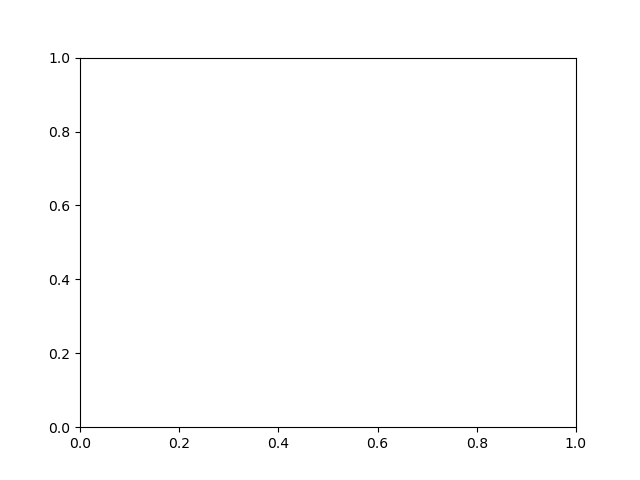

In [35]:
fig=plt.figure()
ax=fig.add_subplot(1,1,1)

In [147]:
stream.stop_stream()
stream.close()
audio.terminate()